In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\tom-i\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

In [8]:
df_da['job_posted_month_no'] = df_da['job_posted_date'].dt.month
df_da

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:41,False,False,France,NaN,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']...",12
18,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau...",10
31,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:31,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,[sql],{'programming': ['sql']},10
34,Data Analyst,Data Analyst als Marketing Manager Automation ...,"Erlangen, Germany",via Central Illinois Proud Jobs,Full-time,False,Germany,2023-02-23 13:31:28,True,False,Germany,NaN,NaN,NaN,DEFACTO GmbH,[sap],{'analyst_tools': ['sap']},2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,1
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,NaN,NaN,NaN,PG&E Corporation,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ...",1
785715,Data Analyst,Amul Careers 2023 - Apply Online - Data Analys...,India,melalui Jobsleworld - Jobs In India - Job Vaca...,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Amul,NaN,NaN,3
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,"[aws, azure]","{'cloud': ['aws', 'azure']}",3


In [10]:
df_da_explode = df_da.explode('job_skills')
df_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='count')


company_name                                              \
job_skills               airflow airtable alteryx angular angular.js ansible   
job_posted_month_no                                                            
1                          197.0     17.0   551.0    63.0        2.0    20.0   
2                          169.0      2.0   448.0    49.0        NaN    14.0   
3                          181.0      4.0   442.0    34.0        NaN    23.0   
4                          155.0      4.0   413.0    22.0        NaN    11.0   
5                          128.0      8.0   310.0    30.0        NaN    19.0   
6                          164.0     14.0   393.0    29.0        NaN    14.0   
7                          207.0      4.0   366.0    15.0        NaN     8.0   
8                          197.0      3.0   413.0    21.0        NaN    12.0   
9                          118.0      4.0   317.0    21.0        NaN    14.0   
10                         173.0     11.0   350.0    40.0        NaN    19.0   
11                         169.0      7.0   293.0    24.0        NaN    19.0   
12                         144.0     10.0   274.0    28.0        NaN    13.0   

                                               ... search_location          \
job_skills            apl  arch asana asp.net  ...           webex windows   
job_posted_month_no                            ...                           
1                     2.0   1.0  29.0    34.0  ...            17.0   228.0   
2                     1.0   4.0  27.0    13.0  ...             9.0   202.0   
3                     6.0   1.0  17.0    13.0  ...             8.0   194.0   
4                     8.0   9.0   9.0    15.0  ...             9.0   185.0   
5                     9.0   2.0   8.0    21.0  ...            11.0   122.0   
6                     9.0   4.0  16.0    16.0  ...             8.0   157.0   
7                     5.0   8.0  19.0    12.0  ...             5.0   161.0   
8                    10.0   3.0  13.0    12.0  ...             9.0   184.0   
9                     3.0  10.0  12.0    10.0  ...             4.0   150.0   
10                    NaN   8.0  11.0    14.0  ...             4.0   156.0   
11                    NaN   5.0   4.0    12.0  ...             4.0   144.0   
12                    NaN   8.0  11.0     9.0  ...             6.0   139.0   

                                                                            
job_skills           wire    word workfront wrike  wsl xamarin  yarn  zoom  
job_posted_month_no                                                         
1                     6.0  1778.0       NaN  11.0  6.0     NaN   9.0  95.0  
2                     6.0  1235.0       4.0   2.0  5.0     NaN   4.0  41.0  
3                     8.0  1203.0       1.0   1.0  3.0     1.0   5.0  45.0  
4                    14.0  1177.0       8.0   2.0  1.0     NaN   6.0  26.0  
5                     3.0   957.0       3.0   4.0  NaN     NaN   7.0  18.0  
6                    14.0  1237.0       6.0   6.0  NaN     NaN  11.0  34.0  
7                    11.0  1069.0       NaN   3.0  NaN     NaN   6.0  38.0  
8                    11.0  1298.0       NaN   1.0  NaN     NaN  11.0  41.0  
9                     8.0   945.0       NaN   1.0  NaN     NaN   5.0  25.0  
10                    8.0   990.0       5.0   2.0  NaN     1.0   4.0  39.0  
11                    4.0   887.0       1.0   1.0  1.0     NaN   6.0  26.0  
12                    8.0   786.0       3.0   5.0  NaN     NaN   2.0  37.0  

[12 rows x 3760 columns]

In [13]:
df_da_explode = df_da.explode('job_skills')
df_da_pivot =df_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)


In [15]:
df_da_pivot


job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [21]:
# we need to create a new row called total to sum up the total count of each skill.
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot.loc['Total'].sort_values(ascending=False)

job_skills
sql          369712
excel        267440
python       228760
tableau      185820
power bi     157520
              ...  
capacitor         4
nuxt.js           4
msaccess          4
ovh               4
suse              4
Name: Total, Length: 235, dtype: int64

In [25]:
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending=False).index]  
df_da_pivot = df_da_pivot.drop('Total')
df_da_pivot                                                   

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


Text(0, 0.5, 'Count')

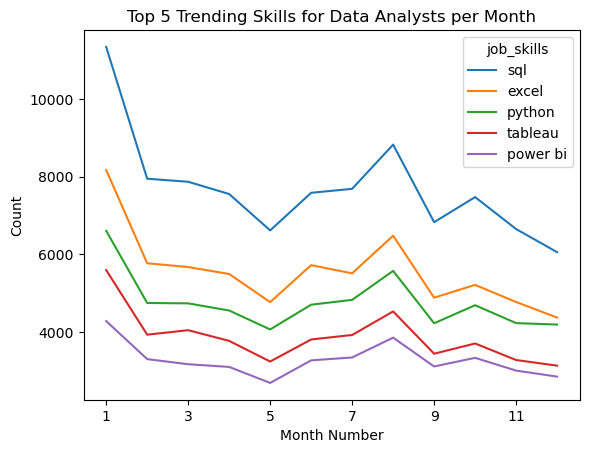

In [29]:
df_da_pivot.iloc[:,:5].plot(kind='line') 
plt.title('Top 5 Trending Skills for Data Analysts per Month')
plt.xlabel('Month Number')
plt.ylabel('Count')